# Numerical results

Companion notebook to *An inverse spectral problem for the wave equation with a varying Robin parameter at the boundary* (Hannukainen, Kulikov, Lassas, Oksanen).

It regenerates the figures and tables of Section 7. 

**Contents**

1. Setup and protocol
2. Test profiles
3. Section 7.1 — boundary sources for $c\equiv 1$
4. Section 7.2 — wave speed reconstructions
5. Choice of the margin $\eta$
6. Section 7.3 — sensitivity to noise in the spectral data

## 1. Setup and protocol

**Data.** The data of the inverse problem are the two finite spectra
$\lbrace\lambda_n(0)\rbrace_{n=1}^{L}$ and $\lbrace\lambda_n(\omega)\rbrace_{n=1}^{L}$,
simulated by P1 finite elements with $L=150$, $\omega=10^{-4}$ and mesh size $h=1/600$.
The true wave speed $c$ enters only this simulation, through the mass matrix, and the scoring.

**Observation time.** The travel time $\tau(1)=\int_0^1 c^{-1}\,dx$ is unknown. It is estimated
from $\lbrace\lambda_n(0)\rbrace$ by fitting the Weyl asymptotics
$\sqrt{\lambda_n(0)}\approx\pi(n-\tfrac12)/\tau(1)+a+b/n$ on $5\le n\le 40$, which gives
$\hat\tau(1)$. The observation time is then
$$
T=(1-\eta)\,\hat\tau(1),\qquad \eta=0.03,
$$
slightly below $\tau(1)$. The margin keeps the front reflected at $x=1$, and the Gibbs
oscillations of the truncated series $\Lambda_L^\omega$ around it, outside the window $[0,2T]$.
The wave speed is recovered on $[0,\hat\chi(T)]$, $\hat\chi(T)=\int_0^T dr/\hat V'(r)$, and continued
on $(\hat\chi(T),1]$ by its last computed value.

**Scoring.** Errors are relative errors on the whole of $[0,1]$. No value of $\hat c$ is
post-processed, except for the linear extrapolation at the right end of profile (d) in Section 4.5.

**Parameters.** The mesh size $N$, the regularization parameters $\alpha,\beta$, the
differentiation method for $V$ and its parameter $\alpha_{\text{reg}}$ are chosen per profile by a
grid search against the true $c$ (Section 4.1). The margin $\eta$ (Section 5) and the parameters of
the linear extrapolation are chosen in the same way. These are oracle choices: the results show the
accuracy the method can reach.

In [1]:
import platform, time, warnings

import numpy as np
import scipy, skfem, matplotlib
from matplotlib import pyplot as plt

import bcm
import forward as fwd
import wavespeed as ws

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

η = 0.03                                    # r_max = (1 − η) τ̂(1)

print("python", platform.python_version(), "| numpy", np.__version__, "| scipy", scipy.__version__,
      "| scikit-fem", skfem.__version__, "| matplotlib", matplotlib.__version__)

python 3.14.7 | numpy 2.5.1 | scipy 1.18.0 | scikit-fem 12.0.2 | matplotlib 3.11.1


## 2. Test profiles

| profile | $c(x)$ | in the admissible class $\mathcal{C}$ |
|---|---|---|
| (a) | $1$ | yes |
| (b) | $1+40\,e^{-1/(s(1-s))}$, $s=(x-0.1)/0.8$ on $(0.1,0.9)$ | yes |
| (c) | smooth plateau $1\to2\to1$ | yes |
| (d) | $1+0.8\sin(\pi x)$ | no, $c'(0)\neq0$ and $c'(1)\neq0$ |
| (e) | $1$ on $[0,0.5]$, $2$ on $(0.5,1]$ | no, discontinuous |
| (f) | piecewise constant, jumps at $0.1$, $0.3$, $0.7$ | no, discontinuous |

In [2]:
def c_a(x):
    return np.ones_like(np.asarray(x, float))

def c_b(x):
    x = np.asarray(x, float); y = np.ones_like(x)
    m = (x > 0.1) & (x < 0.9); s = (x[m] - 0.1)/0.8
    y[m] = 1 + 40*np.exp(-1/(s*(1 - s)))
    return y

def c_c(x):
    def cutoff(z):
        z = np.asarray(z, float); out = np.zeros_like(z)
        m = (0 < z) & (z < 1)
        out[m] = 1/(1 + np.exp(1/(z[m] - 1) + 1/z[m])); out[z >= 1] = 1
        return out
    x = np.asarray(x, float)
    return 1 + np.minimum(cutoff((x - 0.1)/0.2), cutoff((0.9 - x)/0.2))

def c_d(x):
    return 1 + 0.8*np.sin(np.pi*np.asarray(x, float))

def c_e(x):
    return np.where(np.asarray(x, float) <= 0.5, 1.0, 2.0)

def c_f(x):
    x = np.asarray(x, float); out = np.ones_like(x)
    for lo, hi, v in [(0.1, 0.3, 2.5), (0.3, 0.7, 0.8), (0.7, 1.01, 2.0)]:
        out[(lo <= x) & (x < hi)] = v
    return out

PROFILES = {"a": c_a, "b": c_b, "c": c_c, "d": c_d, "e": c_e, "f": c_f}

Helper functions.

* `setup(c, N, data=None, eta=η, ω=1e-4)` builds the inverse problem. `T` is computed from the
  spectral data only. If `data=(λ_0, λ̇_0)` is passed, these data are used instead of the
  simulated ones.
* `errors(ĉ, c, x)` returns relative errors in the discrete norms
  $TV(v)=\sum_i|v_{i+1}-v_i|$, $\max_i|v_i|$, $(\sum_i v_i^2\Delta x)^{1/2}$ and $\sum_i|v_i|\Delta x$.
  If the norm of $c$ vanishes (the $TV$ norm for $c\equiv1$), the relative error is not defined
  and is reported as N/A.

The next cell compares $\hat\tau(1)$ with the true $\tau(1)$, which is used here for this comparison only.

In [3]:
def setup(c, N, data=None, eta=η, ω=1e-4):
    ip = bcm.InvProb(discr=bcm.Discr(N=N, T=1.0), c=c, ω=ω, data=data)
    return ip._replace(discr=bcm.Discr(N=N, T=(1 - eta)*ip.τ_1))


def errors(ĉ, c, x):
    Δx = x[1] - x[0]
    norms = {"TV":  lambda z: np.abs(np.diff(z)).sum(),
             "Loo": lambda z: np.abs(z).max(),
             "L2":  lambda z: np.sqrt((z**2).sum()*Δx),
             "L1":  lambda z: np.abs(z).sum()*Δx}
    v, w = ĉ - c(x), c(x)
    return {key: (nrm(v)/nrm(w) if nrm(w) > 1e-14 else np.nan) for key, nrm in norms.items()}


def fmt(rel):
    return "N/A" if np.isnan(rel) else f"{100*rel:.3g}%"

In [4]:
print(f"{'profile':<9}{'τ(1)':>9}{'τ̂(1)':>9}{'rel. err':>10}{'T':>9}")
for k, c in PROFILES.items():
    ip = setup(c, 100)
    τ = ws.travel_time(c)
    print(f"({k}){'':<6}{τ:>9.5f}{ip.τ_1:>9.5f}{ip.τ_1/τ - 1:>+10.1e}{ip.discr.T:>9.5f}")

profile       τ(1)    τ̂(1)  rel. err        T
(a)        1.00000  0.99719  -2.8e-03  0.96727
(b)        0.85265  0.84996  -3.2e-03  0.82446
(c)        0.68707  0.68453  -3.7e-03  0.66399
(d)        0.68278  0.68065  -3.1e-03  0.66023
(e)        0.75000  0.74723  -3.7e-03  0.72481
(f)        0.83001  0.82136  -1.0e-02  0.79672


The estimate $\hat\tau(1)$ lies slightly below $\tau(1)$. This is the $O(h^2)$ mesh error of the
simulated spectra, not an error of the estimator, and it is on the safe side.

## 3. Section 7.1 — boundary sources for $c\equiv1$

The reconstruction rests on Proposition 2: the source $f_{\alpha,\beta,r}$, computed from the spectral
data alone, generates a wave whose snapshot $u^{f}(T)$ approximates the indicator $\mathbf{1}_{\Omega(r)}$.
Here we check this for the source actually computed from the discrete, truncated data.

**Setting.** $c\equiv1$, $N=100$, $T=(1-\eta)\hat\tau(1)$, $r=t_{70}\approx0.7\,T$. The exact source is
$f=-\delta_{T-r}$, with $\delta_{T-r}$ the Dirac delta at $t=T-r$ (drawn as $-\widehat\varphi_{N-r}/\Delta t$),
and the exact snapshot is $u^f(T)=\mathbf{1}_{\Omega(r)}$ with $\Omega(r)=[0,r]$. Dotted orange lines are
exact, solid blue lines are computed.

**Forward solver.** The wave $u^{f}(T)$ is computed by the finite difference method (FDM), which does
not use the spectral data and therefore gives an independent check. For $c\equiv1$ with equal space
and time steps, the FDM introduces no numerical oscillations, so any oscillations in the figures
come from $f_{\alpha,\beta,r}$ itself.

Two numbers are reported for each $(\alpha,\beta)$:

* the misfit $\varepsilon_u$, the relative $L^2(0,1)$ distance between $u^{f}(T)$ and $\mathbf{1}_{\Omega(r)}$;
* the overshoot $o=\max f/\lvert\min f\rvert$. The exact source is non-positive, so $o>0$ measures
  Gibbs oscillations. A source is called *oscillation-free* if $o<10^{-2}$. For $c\equiv1$,
  $u^f(T,x)=-\int_0^{T-x}f$, so $f\le0$ is equivalent to $u^f(T)$ being monotone.

In [5]:
def leapfrog(f, T, n_t):
    # u^f(T) for c ≡ 1 by leapfrog at Courant number 1 (Δx = Δt = T/n_t).
    # Returns (x, u(T, x)) on x ∈ [0, 1].
    Δ = T/n_t
    J = int(np.ceil(1/Δ))                  # Dirichlet node x_J = JΔ ≥ 1
    x = Δ*np.arange(J + 1)
    F = f(Δ*np.arange(n_t + 1))
    u_old = np.zeros(J + 1)                # u(0, ·) = 0
    u = np.zeros(J + 1)                    # first step, ∂_t u(0, ·) = 0
    u[0] = -Δ*F[0]
    for n in range(1, n_t):
        u_new = np.empty_like(u)
        u_new[1:-1] = u[2:] + u[:-2] - u_old[1:-1]
        u_new[0] = 2*u[1] - u_old[0] - 2*Δ*F[n]
        u_new[-1] = 0.0
        u_old, u = u, u_new
    keep = x <= 1.0 + 1e-12
    return x[keep], u[keep]


ip1 = setup(c_a, 100)
d1 = ip1.discr
N1, T1, Δt1 = d1.N, d1.T, d1.Δt
r_count = 70
node1 = d1.t_node(np.arange(N1))
r1 = node1[r_count - 1]
n_t1 = 2*d1.refined_ix_T                   # leapfrog steps on [0, T]
K1, M1, S1, b1 = bcm.K(ip1), bcm.M(ip1), bcm.S(ip1), bcm.b(d1)
blk = slice(N1 - r_count, N1)


def control(α, β):
    Q = K1 + α*M1 + β*S1
    f = np.zeros(N1)
    f[blk] = np.linalg.solve(Q[blk, blk], b1[blk])
    x, u_T = leapfrog(d1.field(f), T1, n_t1)
    ind = (x <= r1).astype(float)
    ε_u = np.sqrt(np.trapezoid((u_T - ind)**2, x)/np.trapezoid(ind, x))
    return f, x, u_T, ε_u, f.max()/abs(f.min())


def plot_control(α, β):
    f, x, u_T, ε_u, o = control(α, β)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(node1, f, color="C0", lw=1.3, label=r"$f_{\alpha,\beta,r}$")
    ax[0].plot(node1, -d1.φ̂(N1 - r_count)(node1)/Δt1, ":", color="C1", lw=2, label=r"$-\delta_{T-r}$")
    ax[0].set_xlim(0, T1); ax[0].set_xlabel("$t$"); ax[0].legend(fontsize=8)
    ax[1].plot(x, u_T, color="C0", lw=1.3, label=r"$u^{f}(T)$")
    ax[1].plot(x, (x <= r1).astype(float), ":", color="C1", lw=2, label=r"$\mathbf{1}_{\Omega(r)}$")
    ax[1].set_xlim(0, 1); ax[1].set_xlabel("$x$"); ax[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"α = {α:.1e}, β = {β:.1e}:   ε_u = {ε_u:.4f},   overshoot o = {o:+.3f}")
    return ε_u, o


print(f"T = {T1:.5f},  r = {r1:.5f} = {r1/T1:.3f} T,  Δt (controls) = {Δt1:.5f},  "
      f"Δx = Δt (leapfrog) = {T1/n_t1:.2e}")

T = 0.96727,  r = 0.67372 = 0.697 T,  Δt (controls) = 0.00962,  Δx = Δt (leapfrog) = 6.02e-04


### 3.1 The figures of Section 7.1

The text of Section 7.1 also mentions $\alpha=10^{-3}$, $\beta=0$, without a figure.

In [285]:
_, _, _, ε, o = control(1e-3, 0.0)
print(f"α = 1.0e-03, β = 0.0e+00:   ε_u = {ε:.4f},   overshoot o = {o:+.3f}   (text only, no figure)")

α = 1.0e-03, β = 0.0e+00:   ε_u = 0.1469,   overshoot o = +0.000   (text only, no figure)


**Figure 2** — $\alpha=2\cdot10^{-4}$, $\beta=0$

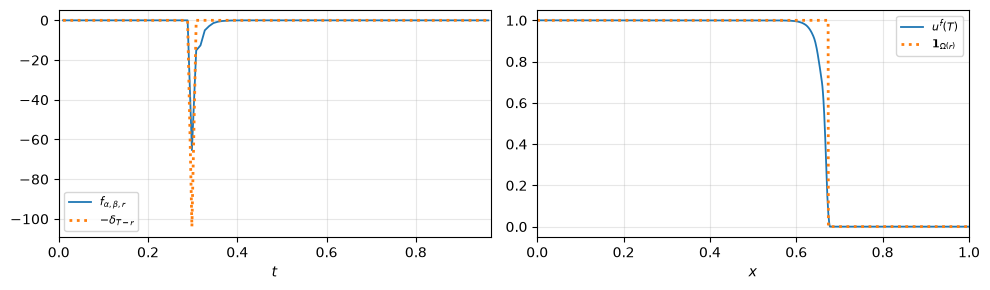

α = 2.0e-04, β = 0.0e+00:   ε_u = 0.0965,   overshoot o = +0.000


In [21]:
plot_control(2e-4, 0.0);

**Figure 3** — $\alpha=10^{-5}$, $\beta=0$

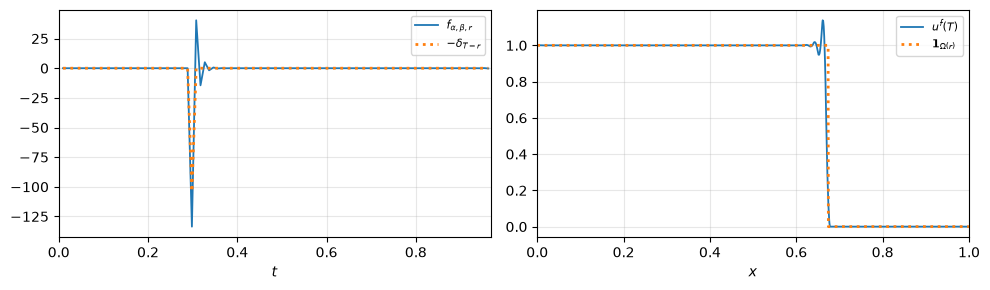

α = 1.0e-05, β = 0.0e+00:   ε_u = 0.0601,   overshoot o = +0.302


In [290]:
plot_control(1e-5, 0.0);

**Figure 4** — $\alpha=6\cdot10^{-5}$, $\beta=0$

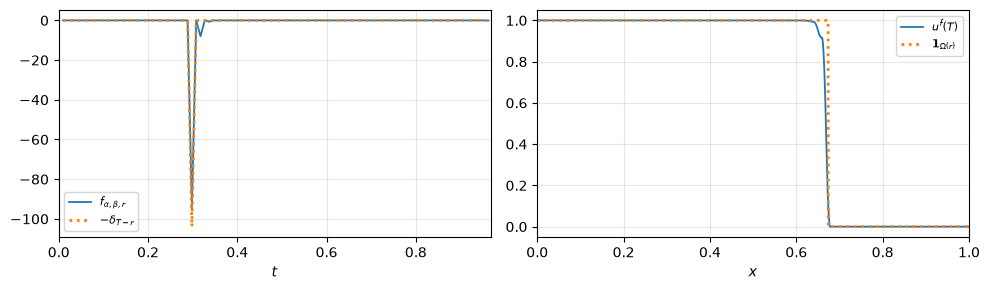

α = 6.0e-05, β = 0.0e+00:   ε_u = 0.0736,   overshoot o = +0.000


In [316]:
plot_control(6e-5, 0.0);

**Figure 5** — $\alpha=10^{-5}$, $\beta=10^{-9}$

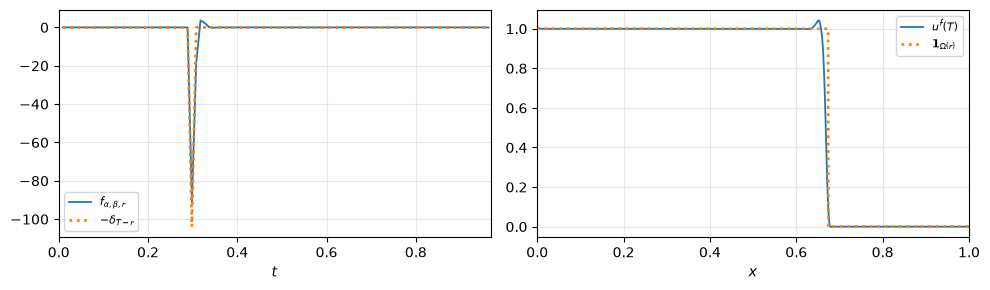

α = 1.0e-05, β = 1.0e-09:   ε_u = 0.0746,   overshoot o = +0.041


In [23]:
plot_control(1e-5, 1e-9);

**Figure 6** — $\alpha=10^{-5}$, $\beta=10^{-11}$

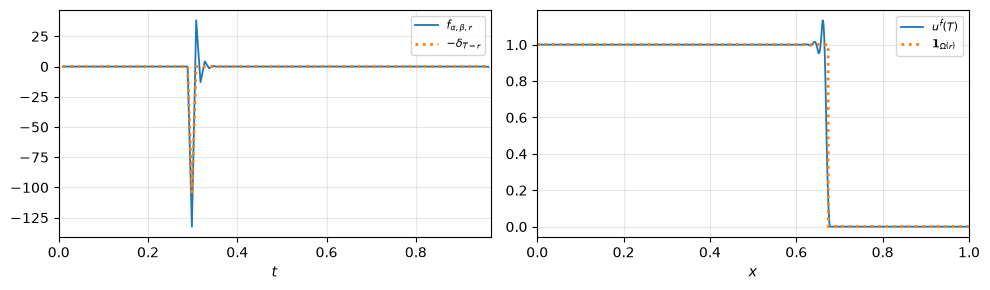

α = 1.0e-05, β = 1.0e-11:   ε_u = 0.0603,   overshoot o = +0.289


In [26]:
plot_control(1e-5, 1e-11);

**Figure 7** — $\alpha=3\cdot10^{-5}$, $\beta=3\cdot10^{-10}$

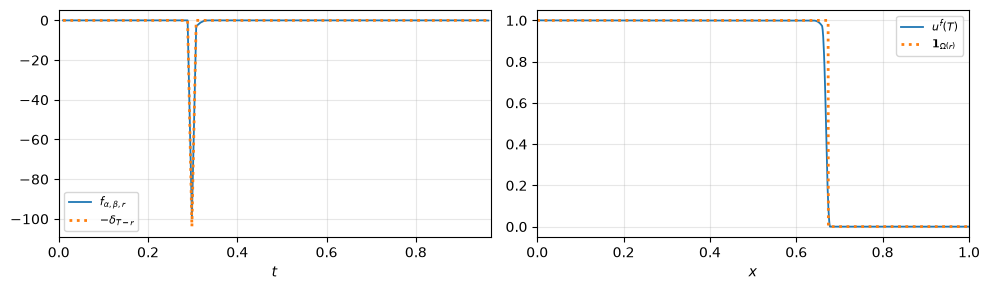

α = 3.0e-05, β = 3.0e-10:   ε_u = 0.0707,   overshoot o = +0.000


In [342]:
plot_control(3e-5, 3e-10);

### 3.2 Pure $L^2$ against joint $L^2$–$H^1$ penalty

Grid: 20 values of $\alpha\in[10^{-5},10^{-3}]$ and $\beta\in\lbrace0\rbrace\cup[10^{-10},10^{-9}]$
(21 values). Reported: the best oscillation-free source with $\beta=0$, and the best oscillation-free
pair $(\alpha,\beta)$ overall. The $H^1$ term suppresses the Gibbs oscillations and so permits a
smaller $\alpha$, that is, a sharper source.

β = 0, oscillation-free optimum:  α = 6.95e-05,               ε_u = 0.0758
joint oscillation-free optimum:   α = 2.07e-05, β = 2.98e-10,  ε_u = 0.0685
the joint L²–H¹ penalty lowers ε_u by 9.6%


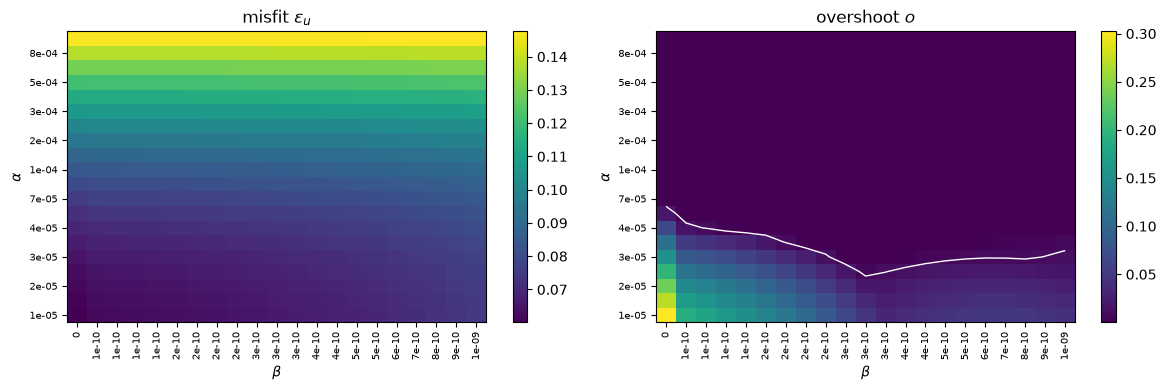

In [17]:
αs = np.geomspace(1e-5, 1e-3, 20)
βs = np.concatenate([[0.0], np.geomspace(1e-10, 1e-9, 20)])
E_u = np.zeros((len(αs), len(βs))); O = np.zeros_like(E_u)
for i, α in enumerate(αs):
    for j, β in enumerate(βs):
        *_, E_u[i, j], O[i, j] = control(α, β)

free = O < 1e-2
i0 = np.argmin(np.where(free[:, 0], E_u[:, 0], np.inf))
ij = np.unravel_index(np.argmin(np.where(free, E_u, np.inf)), E_u.shape)
best_α, best_β = αs[ij[0]], βs[ij[1]]
print(f"β = 0, oscillation-free optimum:  α = {αs[i0]:.2e},               ε_u = {E_u[i0, 0]:.4f}")
print(f"joint oscillation-free optimum:   α = {best_α:.2e}, β = {best_β:.2e},  ε_u = {E_u[ij]:.4f}")
print(f"the joint L²–H¹ penalty lowers ε_u by {100*(1 - E_u[ij]/E_u[i0, 0]):.1f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = ["0"] + [f"{b:.0e}" for b in βs[1:]]
for a, Z, title in [(ax[0], E_u, r"misfit $\varepsilon_u$"), (ax[1], O, "overshoot $o$")]:
    im = a.imshow(Z, origin="lower", aspect="auto", cmap="viridis")
    a.set_xticks(range(len(βs)), labels, rotation=90, fontsize=7)
    a.set_yticks(range(0, len(αs), 2), [f"{v:.0e}" for v in αs[::2]], fontsize=7)
    a.set_xlabel(r"$\beta$"); a.set_ylabel(r"$\alpha$"); a.set_title(title); a.grid(False)
    plt.colorbar(im, ax=a)
ax[1].contour(O, levels=[1e-2], colors="w", linewidths=1)
plt.tight_layout(); plt.show()

The white line in the right panel is the boundary $o=10^{-2}$ of the oscillation-free region. The joint optimum on the grid:

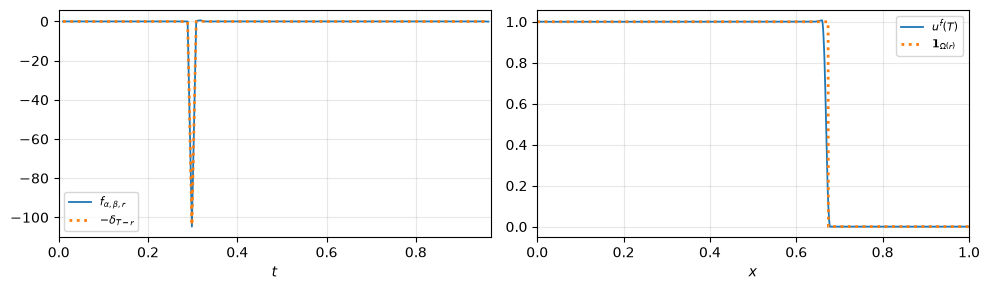

α = 2.1e-05, β = 3.0e-10:   ε_u = 0.0685,   overshoot o = +0.005


In [27]:
plot_control(best_α, best_β);

## 4. Section 7.2 — wave speed reconstructions

Six profiles are reconstructed from their simulated spectra (Figure 8), and the relative errors are
computed on the whole of $[0,1]$ (Table 1).

### 4.1 Parameter search

For each profile, $(\alpha,\beta)$ and the regularization $\alpha_{\text{reg}}$ of $V'$ are chosen on a grid
by minimizing the relative $L^2$ error against the true $c$; the mesh size $N$ is fixed per profile.
The smooth profiles (a)–(d) use the spline or the Tikhonov-$H^1$ method, and the piecewise constant
profiles (e), (f) use TV. The search is done at $\eta=0.03$. This is an oracle choice, and the other
norms in Table 1 are reported for the same parameters.

In [42]:
import itertools

CFG = {  #   N     α      β      method    α_reg
    "a": (500,  1e-6,  1e-10, "spline", 1e-8),
    "b": (1000, 1e-10, 1e-12, "h1",     1e-3),
    "c": (300,  1e-8,  1e-11, "spline", 1e-9),
    "d": (500,  1e-7,  1e-11, "spline", 1e-10),
    "e": (300,  1e-7,  1e-11, "tv",     1e-3),
    "f": (500,  1e-9,  1e-11, "tv",     1e-6),
}
A_GRID = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]          # α
B_GRID = [1e-12, 1e-11, 1e-10, 1e-9]                    # β
REG_GRID = {"spline": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6],
            "h1":     [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
            "tv":     [1e-6, 1e-5, 1e-4, 1e-3, 1e-2]}
METHODS = {k: ("spline", "h1") for k in "abcd"} | {k: ("tv",) for k in "ef"}

best = {}
t0 = time.time()
for k in CFG:
    N = CFG[k][0]
    c = PROFILES[k]
    ip = setup(c, N)
    # K, M, S, b do not depend on (α, β): assemble them once per profile
    K_, M_, S_, b_ = bcm.K(ip), bcm.M(ip), bcm.S(ip), bcm.b(ip.discr)
    r_all = ip.discr.t_node(np.arange(N))
    keep = r_all <= ip.τ_1                               # the truncation of bcm.V
    cand = []
    for α, β in itertools.product(A_GRID, B_GRID):
        V = (bcm._solve_over_r(K_ + α*M_ + β*S_, b_) @ b_)[keep]
        r = r_all[keep]
        for m in METHODS[k]:
            for a in REG_GRID[m]:
                try:
                    ĉ, x = ws.reconstruct_c(V, r, ip, α_reg=a, method=m)
                    e = errors(ĉ, c, x)["L2"]
                except Exception:
                    e = np.inf
                if np.isfinite(e):
                    cand.append((e, α, β, m, a))
    cand.sort(key=lambda z: z[0])
    best[k] = cand[0]
    e, α, β, m, a = cand[0]
    print(f"({k})  best L² error {100*e:.3f}%   α = {α:.0e}, β = {β:.0e}, {m}, α_reg = {a:.0e}"
          f"   [{time.time() - t0:.0f} s]")

print("\nCFG = {  #   N     α      β      method    α_reg")
for k, (e, α, β, m, a) in best.items():
    print(f'    "{k}": ({CFG[k][0]:<4}, {α:.0e}, {β:.0e}, {m!r:<9}, {a:.0e}),')
print("}")

(a)  best L² error 0.004%   α = 1e-10, β = 1e-10, spline, α_reg = 1e-09   [2 s]
(b)  best L² error 0.200%   α = 1e-07, β = 1e-12, h1, α_reg = 1e-03   [15 s]
(c)  best L² error 0.323%   α = 1e-06, β = 1e-11, h1, α_reg = 1e-04   [15 s]
(d)  best L² error 0.323%   α = 1e-06, β = 1e-11, spline, α_reg = 1e-10   [17 s]
(e)  best L² error 1.292%   α = 1e-06, β = 1e-11, tv, α_reg = 1e-03   [24 s]
(f)  best L² error 4.649%   α = 1e-10, β = 1e-11, tv, α_reg = 1e-06   [44 s]

CFG = {  #   N     α      β      method    α_reg
    "a": (500 , 1e-10, 1e-10, 'spline' , 1e-09),
    "b": (1000, 1e-07, 1e-12, 'h1'     , 1e-03),
    "c": (300 , 1e-06, 1e-11, 'h1'     , 1e-04),
    "d": (500 , 1e-06, 1e-11, 'spline' , 1e-10),
    "e": (300 , 1e-06, 1e-11, 'tv'     , 1e-03),
    "f": (500 , 1e-10, 1e-11, 'tv'     , 1e-06),
}


### 4.2 Parameters

The parameters found by the search. Common to all profiles: $L=150$, $\omega=10^{-4}$, $h=1/600$,
$\eta=0.03$.

In [5]:
CFG = {  #   N     α      β      method    α_reg
    "a": (500 , 1e-10, 1e-10, 'spline' , 1e-09),
    "b": (1000, 1e-07, 1e-12, 'h1'     , 1e-03),
    "c": (300 , 1e-06, 1e-11, 'h1'     , 1e-04),
    "d": (500 , 1e-06, 1e-11, 'spline' , 1e-10),
    "e": (300 , 1e-06, 1e-11, 'tv'     , 1e-03),
    "f": (500 , 1e-10, 1e-11, 'tv'     , 1e-06),
}

def reconstruct(k, data=None, scale=1.0):
    # scale multiplies α, β and the regularization of V' (squared for the spline)
    N, α, β, m, a = CFG[k]
    ip = setup(PROFILES[k], N, data)
    V, r = bcm.V(α * scale, β * scale, ip)
    a = a * scale**2 if m == "spline" else a * scale
    ĉ, x = ws.reconstruct_c(V, r, ip, α_reg=a, method=m)
    return ĉ, x, V, r, ip

print(f"{'profile':<9}{'N':>6}{'α':>9}{'β':>9}{'V′ method':>11}{'α_reg':>9}")
for k, (N, α, β, m, a) in CFG.items():
    print(f"({k}){'':<6}{N:>6}{α:>9.0e}{β:>9.0e}{m:>11}{a:>9.0e}")

profile       N        α        β  V′ method    α_reg
(a)         500    1e-10    1e-10     spline    1e-09
(b)        1000    1e-07    1e-12         h1    1e-03
(c)         300    1e-06    1e-11         h1    1e-04
(d)         500    1e-06    1e-11     spline    1e-10
(e)         300    1e-06    1e-11         tv    1e-03
(f)         500    1e-10    1e-11         tv    1e-06


### 4.3 Reconstructions (Figure 8)

Solid black: reconstruction $\hat c$. Dashed orange: exact $c$.

(a)   0.3 s
(b)   1.5 s
(c)   0.1 s
(d)   0.2 s
(e)   0.4 s
(f)   0.4 s


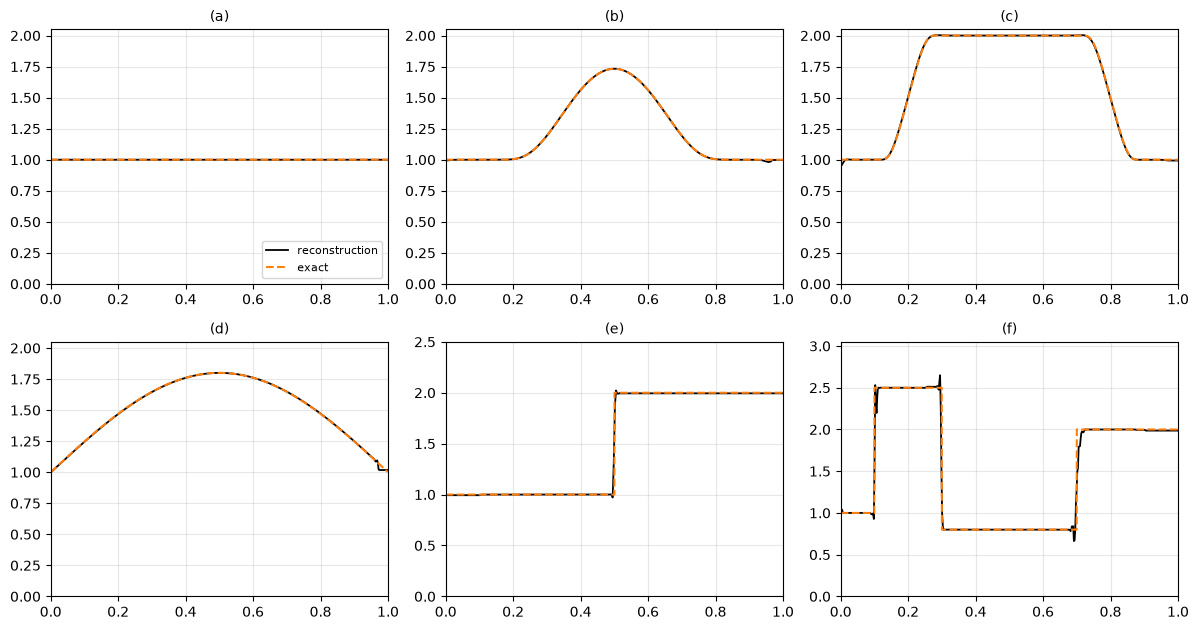

In [6]:
RES = {}
for k in CFG:
    t0 = time.time()
    ĉ, x, V, r, ip = reconstruct(k)
    RES[k] = dict(ĉ=ĉ, x=x, err=errors(ĉ, PROFILES[k], x))
    print(f"({k})  {time.time() - t0:4.1f} s")

fig, axs = plt.subplots(2, 3, figsize=(12, 6.4))
top = {"a": 2.05, "b": 2.05, "c": 2.05, "d": 2.05, "e": 2.5, "f": 3.05}
xf = np.linspace(0, 1, 2001)
for ax, (k, R) in zip(axs.flat, RES.items()):
    ax.plot(R["x"], R["ĉ"], color="k", lw=1.3, label="reconstruction")
    ax.plot(xf, PROFILES[k](xf), "--", color="C1", lw=1.5, label="exact")
    ax.set_xlim(0, 1); ax.set_ylim(0, top[k]); ax.set_title(f"({k})", fontsize=10)
axs[0, 0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

### 4.4 Errors (Table 1)

Relative errors $\lVert\hat c-c\rVert/\lVert c\rVert$ in percent, on the whole of $[0,1]$, without
post-processing. For (d), Table 1 of the paper reports the values after the linear extrapolation of
Section 4.5.

In [7]:
KEYS = ["TV", "Loo", "L2", "L1"]
print(f"{'metric':<8}" + "".join(f"{'(' + k + ')':>10}" for k in RES))
for q in KEYS:
    print(f"{q:<8}" + "".join(f"{fmt(R['err'][q]):>10}" for R in RES.values()))

metric         (a)       (b)       (c)       (d)       (e)       (f)
TV             N/A     3.27%     5.59%     10.4%      102%      175%
Loo          0.01%     1.11%      2.6%     2.65%       16%     38.4%
L2        0.00366%      0.2%    0.323%    0.323%     1.29%     4.65%
L1        0.00277%   0.0718%    0.149%    0.129%    0.344%    0.995%


### 4.5 Linear extrapolation at the right end for (d)

Profile (d) is not in $\mathcal{C}$, since $c'(0)\neq0$ and $c'(1)\neq0$. Its reconstruction is accurate
in the interior, and the violation of the class assumptions affects only the right end. There, the
values of $\hat c$ just before $\hat\chi(T)$ are affected by the end effect of the differentiation of $V$,
and on $(\hat\chi(T),1]$ the reconstruction is only continued constantly, which presumes $c'(1)=0$.

The function `extend_linearly` keeps $\hat c$ on $[0,\hat\chi(T)-\delta]$ and replaces it on
$(\hat\chi(T)-\delta,1]$ by the straight line fitted by least squares to its last $k$ values before
$\hat\chi(T)-\delta$. The values $\delta=0.02$ and $k=20$ were chosen empirically. The correction is
particularly effective for (d): since $c''(x)=-0.8\pi^2\sin(\pi x)$ vanishes at $x=1$, the profile is
linear near $x=1$ up to a cubic term. It uses $\hat c$ only and is applied to (d) only.

χ̂(T) = 0.974: ĉ kept on [0, 0.954], line fitted on [0.916, 0.954] and used on (0.954, 1]

                             TV      Loo       L2       L1   max on (0.95,1]
raw                       10.4%    2.65%   0.323%   0.129%             2.65%
linear extrapolation     0.647%    0.17%  0.0953%  0.0865%             0.17%


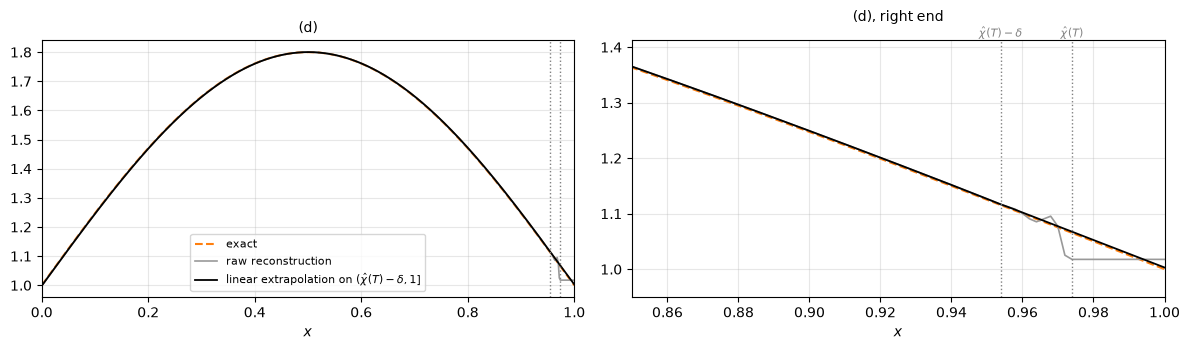

In [8]:
def extend_linearly(ĉ, x, δ=0.02, k=20):
    # keep ĉ on [0, χ̂(T) − δ]; on (χ̂(T) − δ, 1] use the line fitted to the k values before χ̂(T) − δ
    varying = np.flatnonzero(np.abs(np.diff(ĉ)) > 1e-12)
    x_end = x[varying[-1] + 1] if len(varying) else x[-1]          # χ̂(T)
    i0 = np.searchsorted(x, x_end - δ, side="right") - 1            # last kept index
    sl = slice(max(i0 - k + 1, 0), i0 + 1)
    p = np.polyfit(x[sl], ĉ[sl], 1)
    out = ĉ.copy()
    out[i0 + 1:] = np.polyval(p, x[i0 + 1:])
    return out, x[i0], x[sl.start], x_end

ĉ_d, x_d, *_ = reconstruct("d")
ĉ_lin, x0, x_fit, χ_T = extend_linearly(ĉ_d, x_d)
c_d_true = PROFILES["d"]

print(f"χ̂(T) = {χ_T:.3f}: ĉ kept on [0, {x0:.3f}], line fitted on [{x_fit:.3f}, {x0:.3f}] "
      f"and used on ({x0:.3f}, 1]\n")
print(f"{'':22}" + "".join(f"{q:>9}" for q in ["TV", "Loo", "L2", "L1"]) + f"{'max on (0.95,1]':>18}")
for name, ch in [("raw", ĉ_d), ("linear extrapolation", ĉ_lin)]:
    e = errors(ch, c_d_true, x_d)
    tail = 100*np.abs(ch - c_d_true(x_d))[x_d > 0.95].max()/c_d_true(x_d).max()
    print(f"{name:22}" + "".join(f"{fmt(e[q]):>9}" for q in ["TV", "Loo", "L2", "L1"]) + f"{tail:>17.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
xf = np.linspace(0, 1, 2001)
for a_, lim in [(ax[0], (0, 1)), (ax[1], (0.85, 1))]:
    a_.plot(xf, c_d_true(xf), "--", color="C1", lw=1.5, label="exact")
    a_.plot(x_d, ĉ_d, color="0.6", lw=1.2, label="raw reconstruction")
    a_.plot(x_d, ĉ_lin, color="k", lw=1.3, label=r"linear extrapolation on $(\hat\chi(T)-\delta,1]$")
    for xv in (x0, χ_T):
        a_.axvline(xv, color="gray", ls=":", lw=1)
    a_.set_xlim(*lim); a_.set_xlabel("$x$")
m = (xf > 0.85)
top = c_d_true(xf[m]).max() + 0.05
ax[1].set_ylim(0.95, top)
ax[1].text(χ_T, top, r"$\hat\chi(T)$", ha="center", va="bottom", fontsize=8, color="gray")
ax[1].text(x0, top, r"$\hat\chi(T)-\delta$", ha="center", va="bottom", fontsize=8, color="gray")
ax[0].set_title("(d)", fontsize=10); ax[1].set_title("(d), right end", fontsize=10, pad=14)
ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Choice of the margin $\eta$

For $\eta$ from $0.005$ to $0.065$ in steps of $0.005$, the relative $L^2$ error of $\hat c$ is computed
for all six profiles. We take the value that minimizes the largest error over the smooth profiles
(a)–(d). For smaller $\eta$ the errors grow rapidly, since the Gibbs oscillations of $\Lambda_L^\omega$
around the reflected front enter the window. For larger $\eta$ the interval $(\hat\chi(T),1]$, on which
$c$ is only continued constantly, becomes longer. The piecewise constant profiles (e), (f) are shown
for comparison; their error is dominated by the jumps.

done in 31 s

relative L² error (%)
      η      (a)      (b)      (c)      (d)      (e)      (f)   max (a)–(d)
  0.005    4.501    0.809    0.632    4.321    1.318    7.363         4.501
  0.010    1.340    1.774    0.563    2.635    1.275    5.533         2.635
  0.015    0.052    1.001    0.402    3.458    1.251    4.694         3.458
  0.020    0.009    0.379    0.415    1.453    1.263    4.930         1.453
  0.025    0.002    0.939    0.327    0.446    1.278    4.679         0.939
  0.030    0.004    0.200    0.323    0.323    1.292    4.649         0.323
  0.035    0.002    0.656    0.305    0.540    1.275    4.878         0.656
  0.040    0.002    0.182    0.296    0.631    1.208    4.861         0.631
  0.045    0.002    0.278    0.281    0.738    1.085    4.690         0.738
  0.050    0.003    0.321    0.275    0.851    0.951    4.709         0.851
  0.055    0.002    0.068    0.260    0.907    0.901    4.947         0.907
  0.060    0.002    0.158    0.248    1.031    1.043

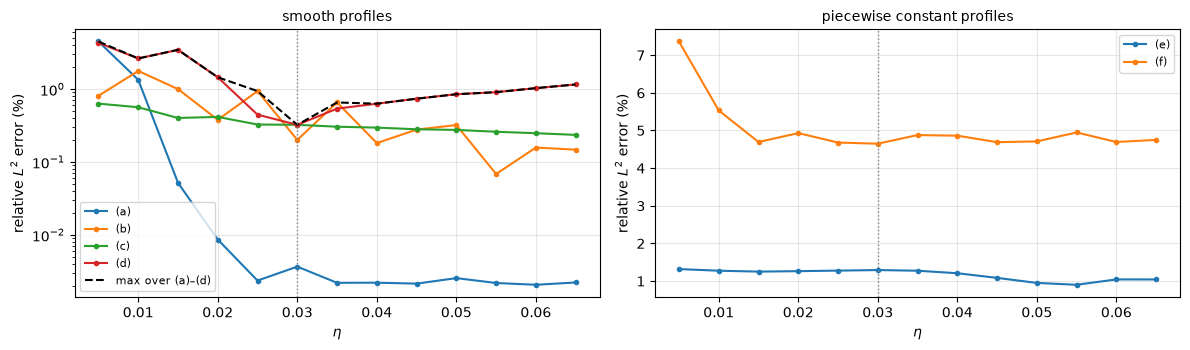

In [9]:
η_grid = np.round(np.arange(0.005, 0.0651, 0.005), 3)
E_η = {}
t0 = time.time()
for k in CFG:
    N, α, β, m, a = CFG[k]
    for η_ in η_grid:
        ip = setup(PROFILES[k], N, eta=η_)
        V, r = bcm.V(α, β, ip)
        try:
            ĉ, x = ws.reconstruct_c(V, r, ip, α_reg=a, method=m)
            E_η[k, η_] = errors(ĉ, PROFILES[k], x)["L2"]
        except Exception:
            E_η[k, η_] = np.inf
print(f"done in {time.time() - t0:.0f} s\n")

print("relative L² error (%)")
print(f"{'η':>7}" + "".join(f"{'(' + k + ')':>9}" for k in CFG) + f"{'max (a)–(d)':>14}")
worst = []
for η_ in η_grid:
    w = max(E_η[k, η_] for k in "abcd")
    worst.append(w)
    print(f"{η_:>7.3f}" + "".join(f"{100*E_η[k, η_]:>9.3f}" for k in CFG) + f"{100*w:>14.3f}")
η_best = η_grid[int(np.argmin(worst))]
print(f"\nη minimizing the largest error over (a)–(d): {η_best}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
for k in "abcd":
    ax[0].semilogy(η_grid, [100*E_η[k, η_] for η_ in η_grid], "o-", ms=3, label=f"({k})")
ax[0].semilogy(η_grid, 100*np.array(worst), "k--", lw=1.5, label="max over (a)–(d)")
ax[0].set_title("smooth profiles", fontsize=10)
for k in "ef":
    ax[1].plot(η_grid, [100*E_η[k, η_] for η_ in η_grid], "o-", ms=3, label=f"({k})")
ax[1].set_title("piecewise constant profiles", fontsize=10)
for a_ in ax:
    a_.axvline(η_best, color="gray", ls=":", lw=1)
    a_.set_xlabel(r"$\eta$"); a_.set_ylabel(r"relative $L^2$ error (%)"); a_.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Section 7.3 — sensitivity to noise in the spectral data

**Noise model.** The measured data are the two spectra. Each is perturbed by independent
multiplicative Gaussian noise,
$$
\tilde\lambda_n(0)=\lambda_n(0)\,(1+\sigma\xi_n),\qquad
\tilde\lambda_n(\omega)=\lambda_n(\omega)\,(1+\sigma\xi_n'),\qquad n=1,\dots,L,
$$
where $\xi_n,\xi_n'\sim\mathcal N(0,1)$ are independent and $\sigma$ is the relative noise level.
Multiplicative noise gives every eigenvalue the same relative accuracy, although
$\lambda_n(0)\asymp n^2$. The derivatives are computed from the perturbed eigenvalues as in the
noise-free case, $\tilde\lambda_n'(0)=(\tilde\lambda_n(\omega)-\tilde\lambda_n(0))/\omega$, and the
perturbed data enter every step, including $\hat\tau(1)$ and hence $T$. All other parameters are
those of Section 4.2.

**Error of the derivative data.** By Taylor's theorem, the error $e_n=\tilde\lambda_n'(0)-\lambda_n'(0)$ is
$$
e_n=\underbrace{\frac{\omega}{2}\,\lambda_n''(\theta_n)}_{\text{modelling error}}
+\underbrace{\frac{\sigma}{\omega}\bigl(\lambda_n(\omega)\xi_n'-\lambda_n(0)\xi_n\bigr)}_{\text{amplified noise}},
\qquad \theta_n\in(0,\omega).
$$
Without noise, only the modelling error remains, of order $\omega$. The standard deviation of the
noise term relative to $|\lambda_n'(0)|$ is $s_n\approx\sqrt2\,\sigma\lambda_n(0)/(\omega|\lambda_n'(0)|)$.
Since $\lambda_n(0)$ increases with $n$ while $|\lambda_n'(0)|=|\phi_n(0)|^2\asymp1$, it is largest at $n=L$,
$$
\rho=\max_{n\le L}s_n\approx\frac{\sigma\lambda_L(0)}{\omega}.
$$
For $\rho\ll1$ all derivative data are accurate, while for $\rho\gg1$ those with $n$ close to $L$ are
dominated by noise. The reconstruction is therefore expected to break down at $\rho\approx1$, that is,
at $\sigma^*\approx\omega/\lambda_L(0)$, a threshold that grows linearly with $\omega$.

The first cell below shows the largest relative error of the derivative data for (d). The second gives
this error and $\rho$ for (c), (d) and (e) at noise levels below and above the threshold.

In [10]:
ωs = [1e-4, 1e-3, 1e-2, 1e-1]
σs = [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
seeds = range(3)
L_ = bcm.InvProb().L

from functools import lru_cache

@lru_cache(maxsize=None)
def exact_spectra(c, ω):
    _, (λ_ω, λ_0), _ = fwd.spectral(c, (ω, 0.0), L_, bcm.InvProb().N_x)
    return λ_ω, λ_0

def noisy_data(c, ω, σ, seed):
    λ_ω, λ_0 = exact_spectra(c, ω)
    rng = np.random.default_rng(seed)
    λ̃_0 = λ_0*(1 + σ*rng.standard_normal(L_))
    λ̃_ω = λ_ω*(1 + σ*rng.standard_normal(L_))
    return λ̃_0, (λ̃_ω - λ̃_0)/ω

# relative error of the derivative data, max over n, profile (d)
_, (λ_0,), φ = fwd.spectral(c_d, (0.0,), L_, bcm.InvProb().N_x)
dλ_exact = -φ[0][0, :]**2                                   # λ_n′(0) = −|φ_n(0)|²
print("max_n |λ̃_n′(0) − λ_n′(0)| / |λ_n′(0)|, profile (d), one realization\n")
print(f"{'σ':>8}" + "".join(f"{'ω = ' + format(ω, '.0e'):>13}" for ω in ωs))
for σ in [0.0] + σs:
    row = [np.max(np.abs(noisy_data(c_d, ω, σ, 0)[1] - dλ_exact)/np.abs(dλ_exact)) for ω in ωs]
    print(f"{σ:>8.0e}" + "".join(f"{v:>13.1e}" for v in row))

max_n |λ̃_n′(0) − λ_n′(0)| / |λ_n′(0)|, profile (d), one realization

       σ    ω = 1e-04    ω = 1e-03    ω = 1e-02    ω = 1e-01
   0e+00      1.2e-05      1.3e-04      1.3e-03      1.3e-02
   1e-11      3.6e-02      3.6e-03      1.3e-03      1.3e-02
   1e-10      3.6e-01      3.6e-02      3.6e-03      1.3e-02
   1e-09      3.6e+00      3.6e-01      3.6e-02      1.3e-02
   1e-08      3.6e+01      3.6e+00      3.6e-01      3.6e-02
   1e-07      3.6e+02      3.6e+01      3.6e+00      3.6e-01
   1e-06      3.6e+03      3.6e+02      3.6e+01      3.6e+00


In [11]:
for k in "cde":
    _, (λ_0,), φ = fwd.spectral(PROFILES[k], (0.0,), L_, bcm.InvProb().N_x)
    dλ_exact = -φ[0][0, :]**2
    for ω, σ in [(1e-4, 1e-10), (1e-4, 1e-9), (1e-1, 1e-7), (1e-1, 1e-6)]:
        err = np.max(np.abs(noisy_data(PROFILES[k], ω, σ, 0)[1] - dλ_exact)/np.abs(dλ_exact))
        print(f"({k})  ω = {ω:.0e}, σ = {σ:.0e}:  data error {err:.2f}   ρ ≈ {σ*λ_0[-1]/ω:.2f}")

(c)  ω = 1e-04, σ = 1e-10:  data error 0.35   ρ ≈ 0.50
(c)  ω = 1e-04, σ = 1e-09:  data error 3.53   ρ ≈ 4.99
(c)  ω = 1e-01, σ = 1e-07:  data error 0.35   ρ ≈ 0.50
(c)  ω = 1e-01, σ = 1e-06:  data error 3.53   ρ ≈ 4.99
(d)  ω = 1e-04, σ = 1e-10:  data error 0.36   ρ ≈ 0.50
(d)  ω = 1e-04, σ = 1e-09:  data error 3.56   ρ ≈ 5.00
(d)  ω = 1e-01, σ = 1e-07:  data error 0.36   ρ ≈ 0.50
(d)  ω = 1e-01, σ = 1e-06:  data error 3.56   ρ ≈ 5.00
(e)  ω = 1e-04, σ = 1e-10:  data error 0.30   ρ ≈ 0.42
(e)  ω = 1e-04, σ = 1e-09:  data error 3.03   ρ ≈ 4.19
(e)  ω = 1e-01, σ = 1e-07:  data error 0.30   ρ ≈ 0.42
(e)  ω = 1e-01, σ = 1e-06:  data error 3.03   ρ ≈ 4.19


At $\sigma=0$ the error of the derivative data is the modelling error, of order $\omega$; for $\sigma>0$
it is proportional to $\sigma/\omega$. At the two noise levels around each threshold, $\rho$ and the data
error are nearly the same for all three profiles and for every $\omega$.

**Reconstruction error.** Relative $L^2$ error of $\hat c$, mean over three realizations. A *breakdown*
means that, for at least one realization, the error exceeds $100\%$ or the computed $V'$ is not positive,
so that $\chi$ cannot be inverted. Once a noise level breaks down, larger $\sigma$ are not run.

In [21]:
def rel_L2(k, data, ω):
    N, α, β, m, a = CFG[k]
    try:
        ip = setup(PROFILES[k], N, data, ω=ω)
        V, r = bcm.V(α, β, ip)
        ĉ, x = ws.reconstruct_c(V, r, ip, α_reg=a, method=m)
        e = errors(ĉ, PROFILES[k], x)["L2"]
        return e if np.isfinite(e) else np.inf
    except Exception:
        return np.inf

NOISE = {}
t0 = time.time()
for k in "cde":
    for ω in ωs:
        NOISE[k, ω, 0.0] = rel_L2(k, noisy_data(PROFILES[k], ω, 0.0, 0), ω)
        broken = False
        for σ in σs:
            if broken:
                NOISE[k, ω, σ] = np.inf; continue
            e = [rel_L2(k, noisy_data(PROFILES[k], ω, σ, s), ω) for s in seeds]
            broken = max(e) > 1.0
            NOISE[k, ω, σ] = np.inf if broken else np.mean(e)
print(f"done in {time.time() - t0:.0f} s\n")

cell = lambda v: "breakdown" if not np.isfinite(v) else f"{100*v:.3f}%"
for k in "cde":
    print(f"profile ({k})")
    print(f"{'σ':>8}" + "".join(f"{'ω = ' + format(ω, '.0e'):>13}" for ω in ωs))
    for σ in [0.0] + σs:
        print(f"{σ:>8.0e}" + "".join(f"{cell(NOISE[k, ω, σ]):>13}" for ω in ωs))
    print()

/tmp/v5/wavespeed.py:96: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  return UnivariateSpline(r, V, s=s, k=4).derivative()(r)


/tmp/v5/wavespeed.py:96: UserWarning: 
A theoretically impossible result was found during the iteration
process for finding a smoothing spline with fp = s: s too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  return UnivariateSpline(r, V, s=s, k=4).derivative()(r)


done in 136 s

profile (c)
       σ    ω = 1e-04    ω = 1e-03    ω = 1e-02    ω = 1e-01
   0e+00       0.375%       0.371%       0.380%       1.900%
   1e-11       0.374%       0.371%       0.380%       1.900%
   1e-10       0.388%       0.371%       0.380%       1.900%
   1e-09    breakdown       0.384%       0.380%       1.900%
   1e-08    breakdown    breakdown       0.390%       1.900%
   1e-07    breakdown    breakdown    breakdown       1.910%
   1e-06    breakdown    breakdown    breakdown    breakdown

profile (d)
       σ    ω = 1e-04    ω = 1e-03    ω = 1e-02    ω = 1e-01
   0e+00       0.351%       0.324%       0.566%       1.923%
   1e-11       0.353%       0.324%       0.566%       1.923%
   1e-10       0.461%       0.325%       0.567%       1.987%
   1e-09    breakdown       0.381%       0.570%       1.987%
   1e-08    breakdown    breakdown       0.679%       1.927%
   1e-07    breakdown    breakdown      34.732%       2.136%
   1e-06    breakdown    breakdown    breakdo

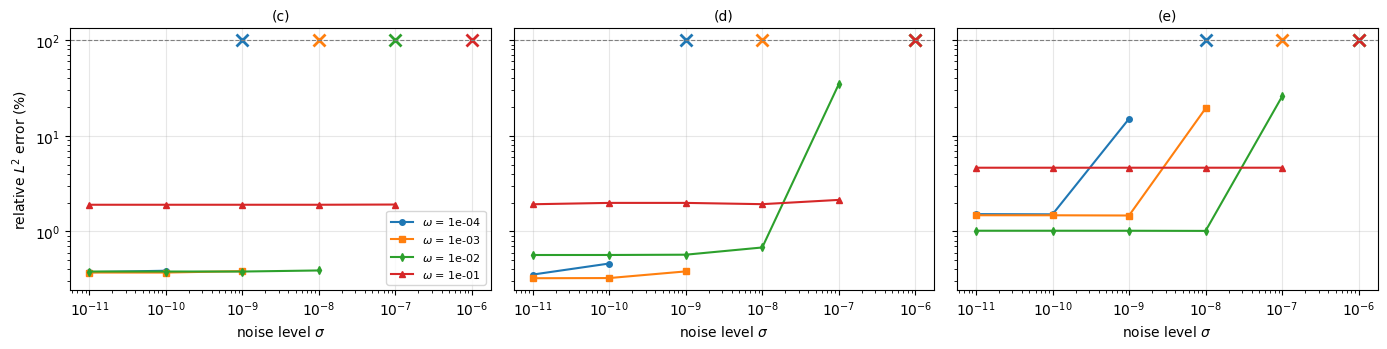

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for ax, k in zip(axs, "cde"):
    for ω, mk in zip(ωs, "osd^"):
        e = np.array([NOISE[k, ω, σ] for σ in σs])
        ok = np.isfinite(e)
        line, = ax.loglog(np.array(σs)[ok], 100*e[ok], mk + "-", ms=4, label=f"$\\omega$ = {ω:.0e}")
        if (~ok).any():
            ax.plot(σs[np.argmax(~ok)], 100, "x", color=line.get_color(), ms=9, mew=2)
    ax.axhline(100, color="gray", lw=0.8, ls="--")
    ax.set_title(f"({k})", fontsize=10); ax.set_xlabel(r"noise level $\sigma$")
axs[0].set_ylabel(r"relative $L^2$ error (%)"); axs[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

Crosses on the dashed $100\%$ line mark the first noise level at which the reconstruction breaks down.

The reconstruction is as accurate as without noise up to a threshold in $\sigma$ and breaks down shortly
beyond it. The threshold grows linearly with $\omega$ and corresponds to $\rho\approx1$ for every $\omega$,
as predicted. A larger $\omega$ tolerates more noise, at the cost of a larger modelling error, visible in
the larger errors for $\omega=10^{-1}$ at small $\sigma$.

## Summary

* **Section 7.1.** The sources computed from the spectral data generate waves that approximate
  $\mathbf{1}_{\Omega(r)}$, as verified with the FDM. The joint $L^2$–$H^1$ penalty permits sharper sources
  without Gibbs oscillations and gives a smaller misfit than the pure $L^2$ penalty.
* **Section 7.2.** The smooth profiles are reconstructed with small errors, concentrated near the
  endpoints of $\Omega$, where the differentiation of $V$ has end effects. For (d), outside $\mathcal{C}$, the
  defect at the right end is removed by the linear extrapolation. For the piecewise constant profiles,
  the constant levels are recovered accurately and the errors are concentrated at the jumps.
* **Section 7.3.** The reconstruction is robust to noise in the spectral data as long as
  $\rho=\sigma\lambda_L(0)/\omega\ll1$.
* **Parameters.** All parameters are oracle choices made with the true $c$; the results show the
  accuracy attainable with the method.